Dataset Shape: (891, 14)

Survival Rate by Sex:
 Sex
female    0.742
male      0.189
Name: Survived, dtype: float64

Survival Rate by Pclass:
 Pclass
1    0.630
2    0.473
3    0.242
Name: Survived, dtype: float64


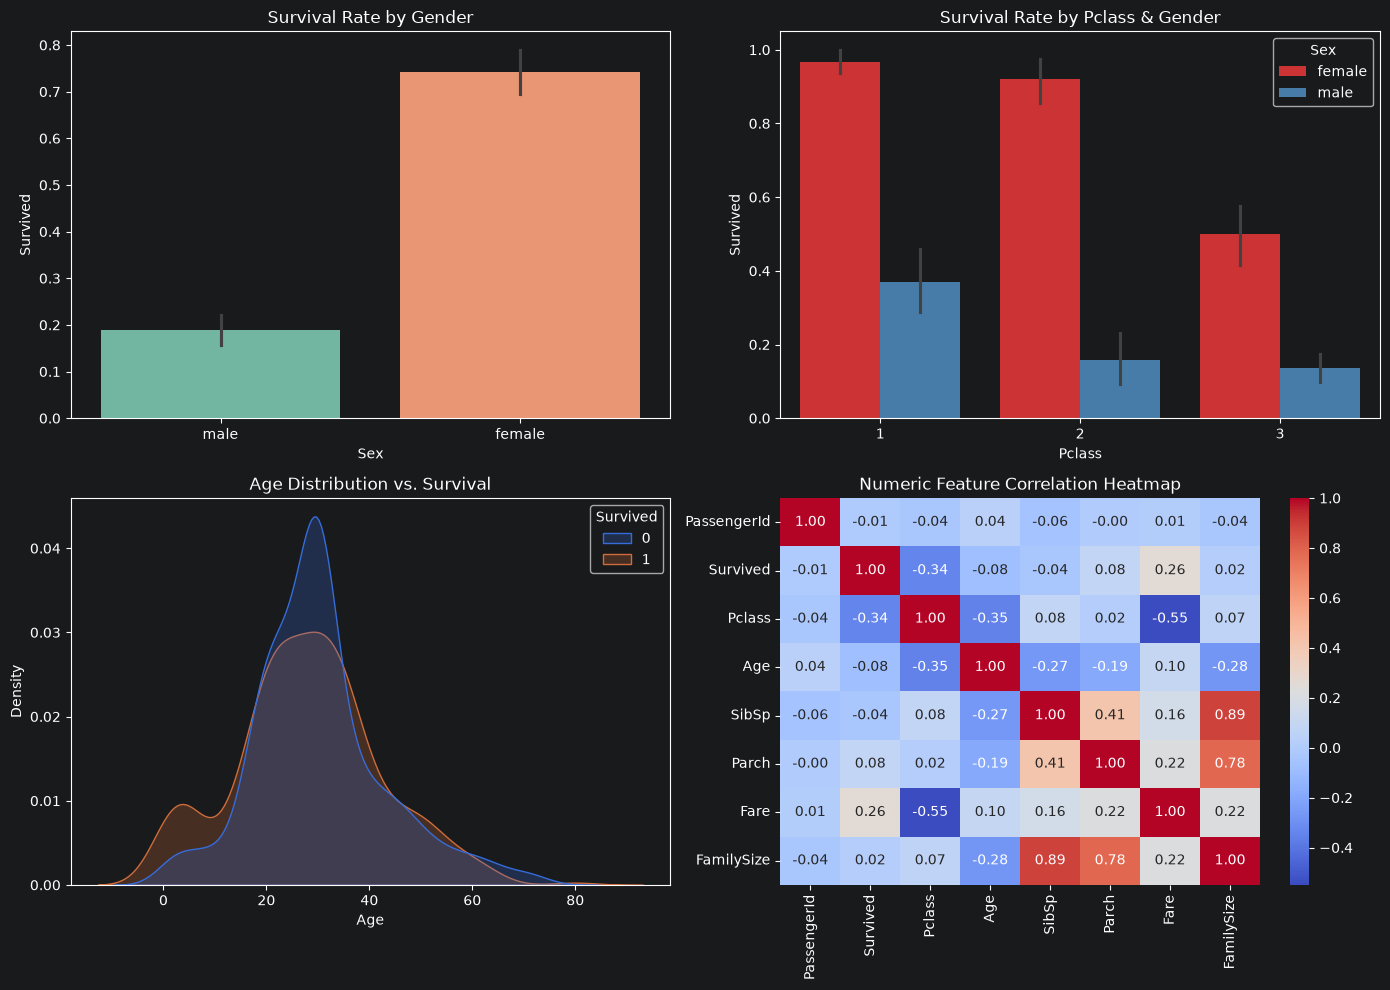

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('titanic.csv')

df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['Age'] = df.groupby('Title')['Age'].transform(lambda x: x.fillna(x.median()))
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

print("Dataset Shape:", df.shape)
print("\nSurvival Rate by Sex:\n", df.groupby('Sex')['Survived'].mean().round(3))
print("\nSurvival Rate by Pclass:\n", df.groupby('Pclass')['Survived'].mean().round(3))


fig, axes = plt.subplots(2, 2, figsize=(14, 10))


sns.barplot(x='Sex', y='Survived', data=df, ax=axes[0, 0], hue='Sex', legend=False, palette='Set2')
axes[0, 0].set_title('Survival Rate by Gender')

sns.barplot(x='Pclass', y='Survived', hue='Sex', data=df, ax=axes[0, 1], palette='Set1')
axes[0, 1].set_title('Survival Rate by Pclass & Gender')

sns.kdeplot(data=df, x='Age', hue='Survived', common_norm=False, ax=axes[1, 0], fill=True)
axes[1, 0].set_title('Age Distribution vs. Survival')


numeric_cols = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f", ax=axes[1, 1])
axes[1, 1].set_title('Numeric Feature Correlation Heatmap')

plt.tight_layout()
plt.show()